In [1]:
import pandas
import numpy
import matplotlib

df = pandas.read_csv('ufo.csv', low_memory=False)
df.head()

,datetime,city,state,country,shape,duration (seconds),duration (hours/min),comments,date posted,latitude,longitude
0,1949-10-10 20:30:00,san marcos,tx,us,cylinder,2700,45 minutes,This event took place in early fall around 194...,2004-04-27,29.8830556,-97.941111
1,1949-10-10 21:00:00,lackland afb,tx,NaN,light,7200,1-2 hrs,1949 Lackland AFB&#44 TX. Lights racing acros...,2005-12-16,29.38421,-98.581082
2,1955-10-10 17:00:00,chester (uk/england),NaN,gb,circle,20,20 seconds,Green/Orange circular disc over Chester&#44 En...,2008-01-21,53.2,-2.916667
3,1956-10-10 21:00:00,edna,tx,us,circle,20,1/2 hour,My older brother and twin sister were leaving ...,2004-01-17,28.9783333,-96.645833
4,1960-10-10 20:00:00,kaneohe,hi,us,light,900,15 minutes,AS a Marine 1st Lt. flying an FJ4B fighter/att...,2004-01-22,21.4180556,-157.803611


## Nettoyage des données
    Avant d'analyser des données on va s'assurer que le jeu de donneés et propre avec des donneés cohérentes

In [2]:
df["state"]=df["state"].fillna("Unknown")
print(df['state'].head())


0         tx
1         tx
2    Unknown
3         tx
4         hi
Name: state, dtype: object


In [3]:
df["state"].describe()

count     80332
unique       68
top          ca
freq       9655
Name: state, dtype: object

<Axes: ylabel='count'>

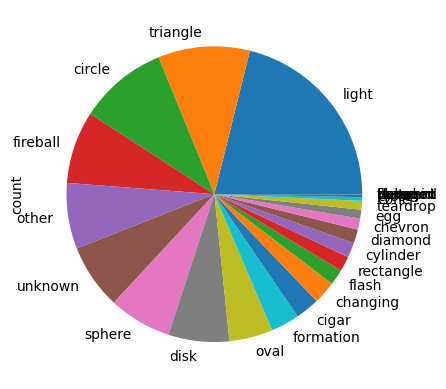

In [4]:
shapeCount = df["shape"].value_counts()
shapeCount.plot.pie()

<Axes: xlabel='state'>

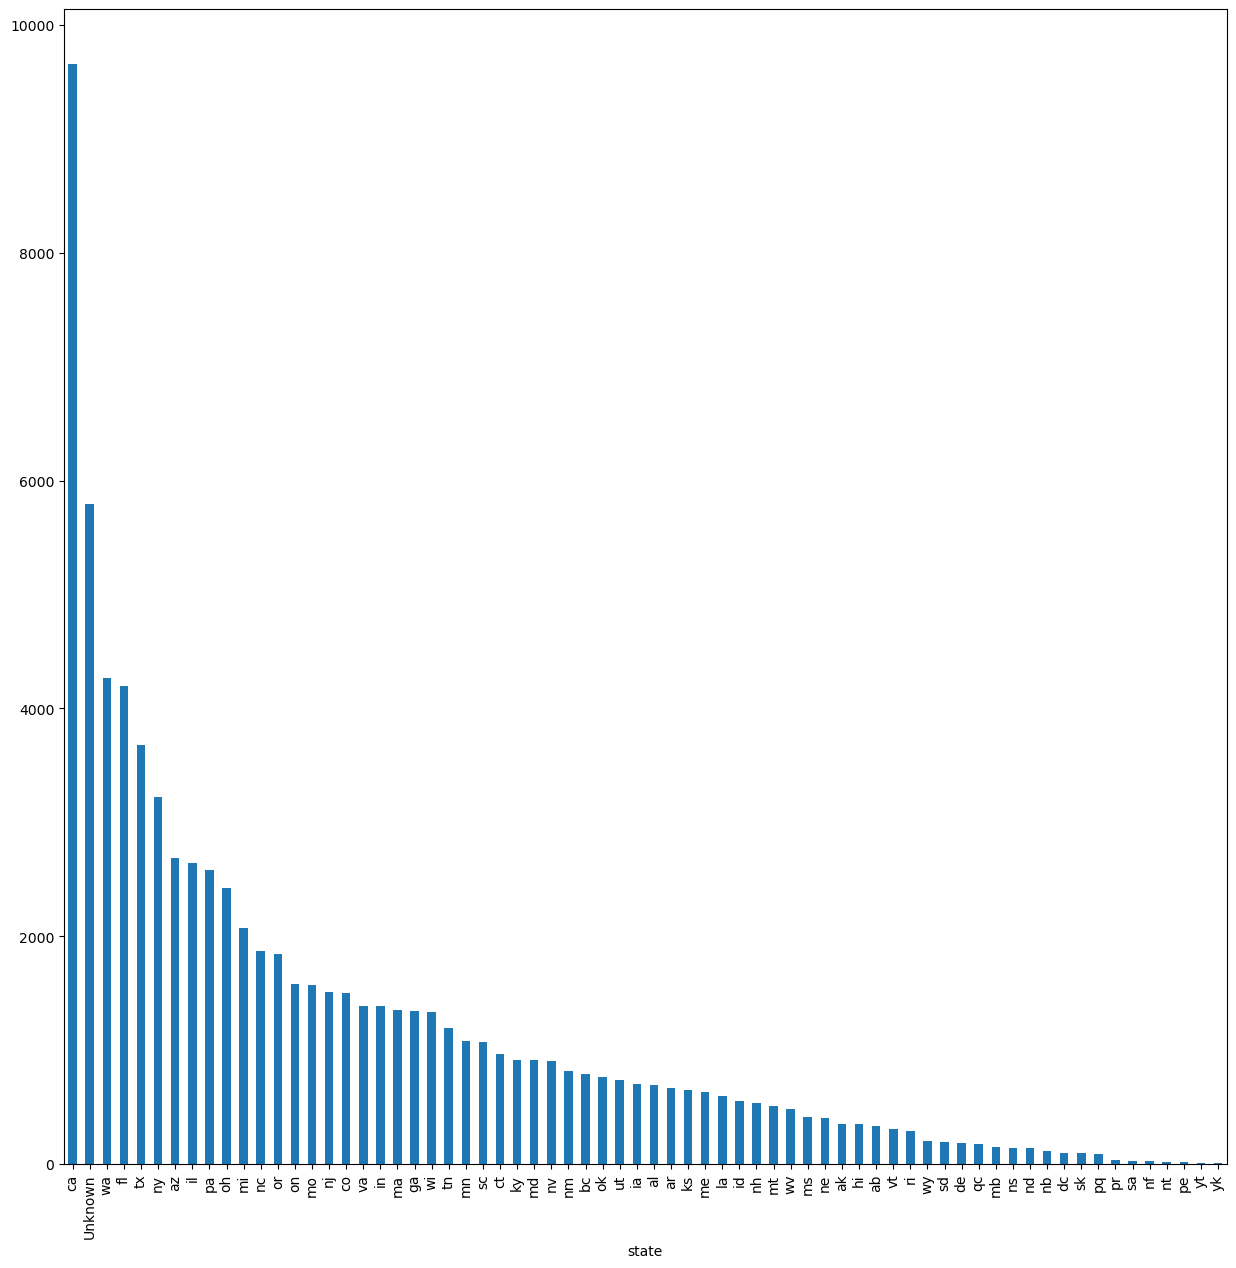

In [5]:
stateC = df["state"].value_counts()
stateC.plot.bar(figsize=(15,15))

### Standardisation de la colonne Duration (hours/min)
Plutôt que de nettoyer du texte incertain, nous utilisons la colonne numérique `duration (seconds)` pour reconstruire une colonne de durée propre et lisible.

In [6]:
def format_duration(seconds_str):
    try:
        # Nettoyage de la chaîne de caractères
        s = str(seconds_str).strip().replace('`','')
        total_seconds = float(s)
        
        if total_seconds >= 3600:
            hours = int(total_seconds // 3600)
            minutes = int((total_seconds % 3600) // 60)
            return f"{hours}h{minutes:02d}"
        elif total_seconds >= 60:
            minutes = int(total_seconds // 60)
            return f"{minutes}m"
        else:
            # Arrondi au plus proche, .5 à l'inférieur
            decimal_part = total_seconds - int(total_seconds)
            if decimal_part > 0.5:
                seconds = int(total_seconds) + 1
            else:
                seconds = int(total_seconds)
            return f"{seconds}s"
    except:
        return numpy.nan

# On écrase la colonne avec le formatage final ultra-précis
df['duration (hours/min)'] = df['duration (seconds)'].apply(format_duration)

print("Aperçu du formatage final avec arrondi intelligent :")
print(df[['duration (seconds)', 'duration (hours/min)']].head(10))

Aperçu du formatage final avec arrondi intelligent :
  duration (seconds) duration (hours/min)
0               2700                  45m
1               7200                 2h00
2                 20                  20s
3                 20                  20s
4                900                  15m
5                300                   5m
6                180                   3m
7               1200                  20m
8                180                   3m
9                120                   2m


### Nettoyage de la colonne Shape
Nous convertissons les valeurs 'unknown' et les cases vides en `NaN` officiel pour une meilleure gestion statistique.

In [7]:
# Remplacement de 'unknown' par NaN (insensible à la casse)
df['shape'] = df['shape'].replace('unknown', numpy.nan)

# S'assurer que les chaînes vides ou espaces sont aussi en NaN
df['shape'] = df['shape'].replace(r'^\s*$', numpy.nan, regex=True)

print(f"Nombre de valeurs manquantes dans 'shape' : {df['shape'].isna().sum()}")
print("Top 5 des formes après nettoyage :")
print(df['shape'].value_counts().head())

Nombre de valeurs manquantes dans 'shape' : 7516
Top 5 des formes après nettoyage :
shape
light       16565
triangle     7865
circle       7608
fireball     6208
other        5649
Name: count, dtype: int64


### Nettoyage Robuste de la colonne City (Strategie de Rappel)
Ce bloc applique un nettoyage par Regex (suffixes, parentheses) puis tente une standardisation via GeoNamesCache (match 100% uniquement). Les villes non reconnues sont preservees.

In [1]:
import html
import re
from rapidfuzz import fuzz, process
import geonamescache

# 1. Initialisation de la base de reference mondiale
gc = geonamescache.GeonamesCache()
cities_data = gc.get_cities()
reference_dict = {}
for c_id, info in cities_data.items():
    name_low = info['name'].lower()
    if name_low not in reference_dict or info['population'] > reference_dict[name_low][1]:
        reference_dict[name_low] = (info['name'], info['population'])

clean_reference_dict = {k: v[0] for k, v in reference_dict.items()}
reference_list = list(clean_reference_dict.keys())

# 2. Definition des filtres de bruit
noise_regex = re.compile(r'\b(afb|nas|station|county|airport|base|field|uk|usa|canada)\b', re.IGNORECASE)

def final_clean_city(name):
    if pandas.isna(name): return numpy.nan
    
    # Pretraitement rigoureux
    name = html.unescape(str(name)).lower()
    # On coupe au premier /, 'and' ou parenthese ouvrante
    name = re.split(r'/|\band\b|\(', name)[0]
    # Retrait des suffixes
    name = noise_regex.sub('', name)
    name = name.replace('?', '').strip()
    
    if not name or any(char.isdigit() for char in name):
        return numpy.nan
    
    # Standardization (Match 100% uniquement via token_set_ratio)
    result = process.extractOne(name, reference_list, scorer=fuzz.token_set_ratio, score_cutoff=100)
    
    if result:
        return clean_reference_dict[result[0]]
    
    # Safe Recall : on garde le nom nettoye si pas de match parfait
    return name

# 3. Application optimisee sur les valeurs uniques
unique_cities = df['city'].unique()
mapping = {city: final_clean_city(city) for city in unique_cities}
df['city'] = df['city'].map(mapping)

print("Nettoyage expert de la colonne 'city' termine.")
print(f"Nombre de villes uniques apres traitement : {df['city'].nunique()}")

NameError: name 'df' is not defined

analyse : le film E.T. de Steven spielberg sortie en 1982 a t-il un incidence sur le nombre d'ovnie vue et réferencé ?

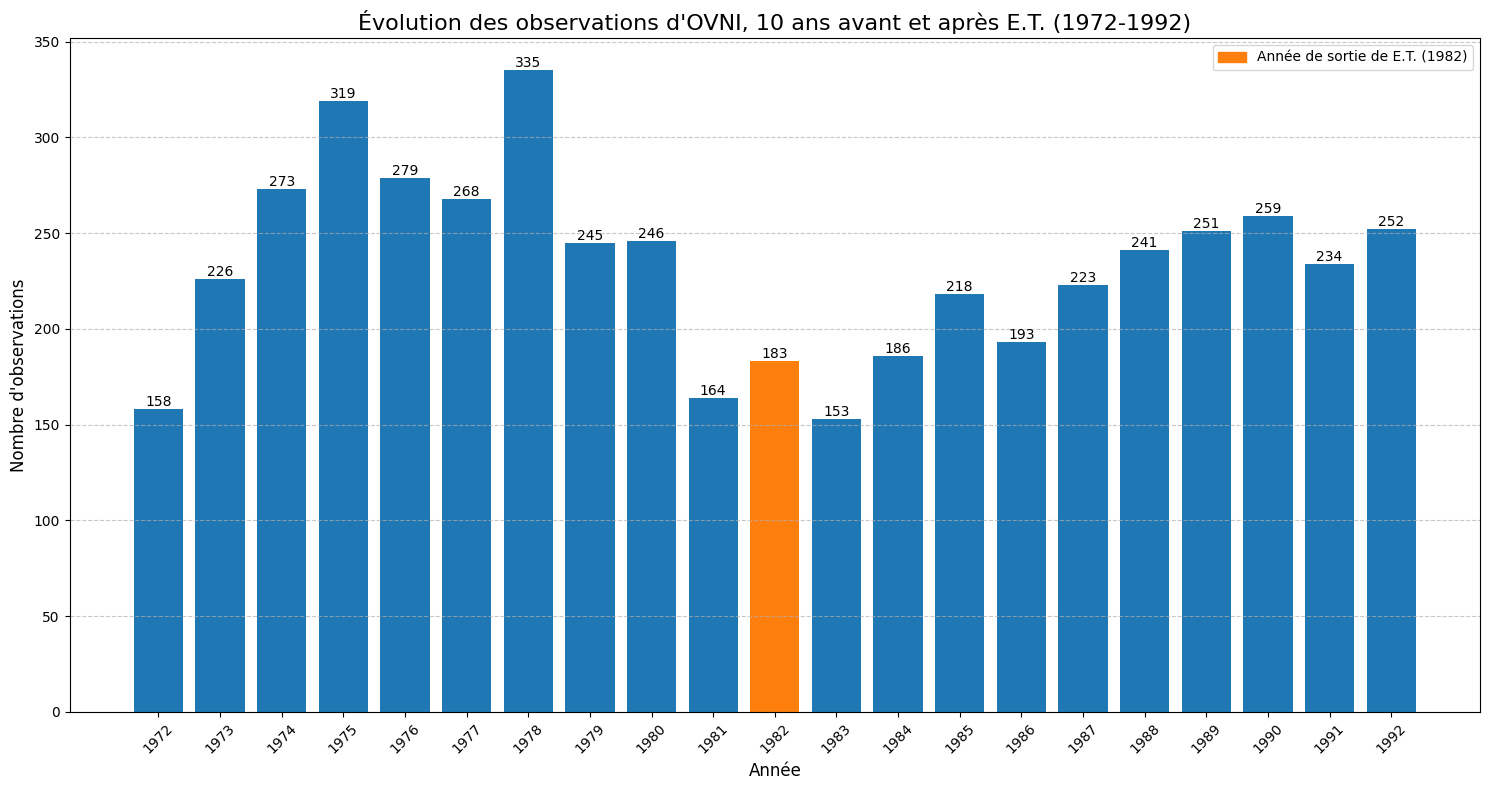

In [ ]:
import matplotlib.pyplot as plt
import pandas
import matplotlib.patches as mpatches

df['datetime'] = pandas.to_datetime(df['datetime'])
df.dropna(subset=['datetime'], inplace=True)
df['year'] = df['datetime'].dt.year.astype(int)

# On prend un periode de 20 ans 10 ans avant le film et 10 ans après le filù
start_year = 1972  
end_year = 1992   
df_focus = df[(df['year'] >= start_year) & (df['year'] <= end_year)]
# On s'assure qu'on affiche les années même si il n'y a pas d'observations
sightings_by_year = df_focus.groupby('year').size()
all_years = pandas.RangeIndex(start=start_year, stop=end_year + 1)
sightings_by_year = sightings_by_year.reindex(all_years, fill_value=0)

#Création du diagramme
plt.figure(figsize=(15, 8))


colors = ['#ff7f0e' if year == 1982 else '#1f77b4' for year in sightings_by_year.index]

bars = plt.bar(sightings_by_year.index, sightings_by_year.values, color=colors)

plt.title("Évolution des observations d'OVNI, 10 ans avant et après E.T. (1972-1992)", fontsize=16)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre d'observations", fontsize=12)
plt.xticks(sightings_by_year.index, rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)



orange_patch = mpatches.Patch(color='#ff7f0e', label='Année de sortie de E.T. (1982)')
plt.legend(handles=[orange_patch])

for bar in bars:
    yval = bar.get_height()
    if yval > 0:
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

On voit que le film E.T n'a pas vraiment d'impact sur l'observation d'ovni il y en autant voir plus avant la diffusion du film qu'après est même sur l'année de sortie on n'observe pas plus d'obeservation que d'autre année comme 1975 et 1978